In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pickle
import sys
sys.path.append('..')
from src.model import NRMSModel
from src.train import MINDDataset, train
from torch.utils.data import DataLoader

In [2]:
with open('../data/processed/news_encoded.pkl', 'rb') as f:
    news_encoded = pickle.load(f)

with open('../data/processed/samples.pkl', 'rb') as f:
    samples = pickle.load(f)

with open('../data/processed/samples_dev.pkl', 'rb') as f:
    samples_dev = pickle.load(f)

embedding_matrix = np.load('../data/processed/embedding_matrix.npy')

print(f'Train samples: {len(samples)}')
print(f'Dev samples: {len(samples_dev)}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Train samples: 236344
Dev samples: 111383
Embedding matrix shape: (20774, 300)


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 5
NEG_SAMPLE_K = 4
MAX_HISTORY = 50
MAX_TITLE_LEN = 30
NUM_HEADS = 16
HEAD_DIM = 16

Using device: cuda


In [4]:
def collate_fn(batch):
    history = torch.stack([b['history'] for b in batch])
    candidates = torch.stack([b['candidates'] for b in batch])
    hist_mask = torch.stack([b['hist_mask'] for b in batch])
    labels = [b['labels'] for b in batch]
    return {
        'history': history,
        'candidates': candidates,
        'hist_mask': hist_mask,
        'labels': labels
    }

In [5]:
train_dataset = MINDDataset(samples, MAX_HISTORY, MAX_TITLE_LEN, NEG_SAMPLE_K)
dev_dataset = MINDDataset(samples_dev, MAX_HISTORY, MAX_TITLE_LEN, NEG_SAMPLE_K)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Dev batches: {len(dev_loader)}')

Train batches: 3693
Dev batches: 1741


Epoch 1/5, Loss: 1.4425
Epoch 2/5, Loss: 1.3602
Epoch 3/5, Loss: 1.3264
Epoch 4/5, Loss: 1.3067
Epoch 5/5, Loss: 1.2893


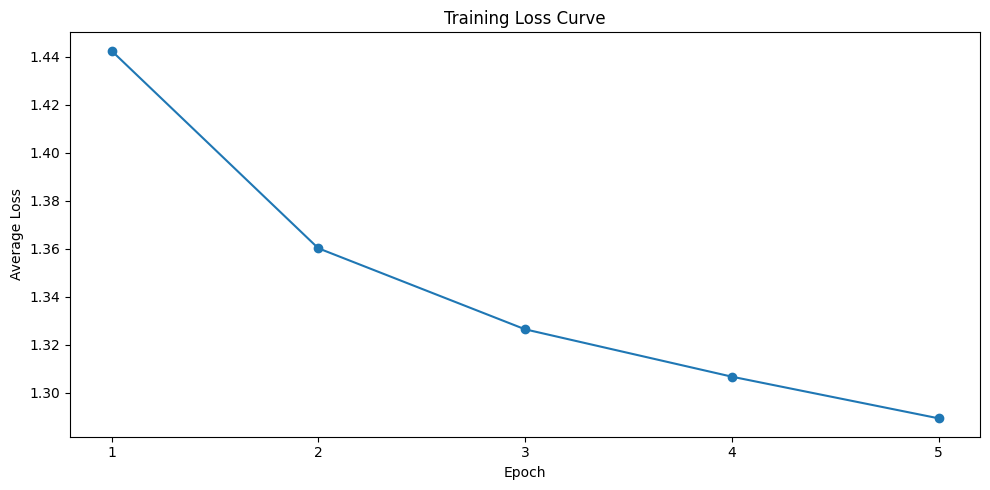

Loss curve saved to results/loss_curve.png


In [7]:
model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

epoch_losses = train(model, train_loader, optimizer, criterion, device, EPOCHS, '../models')

Epoch 1/5, Loss: 1.4021
Epoch 2/5, Loss: 1.3249
Epoch 3/5, Loss: 1.2903
Epoch 4/5, Loss: 1.2687
Epoch 5/5, Loss: 1.2528


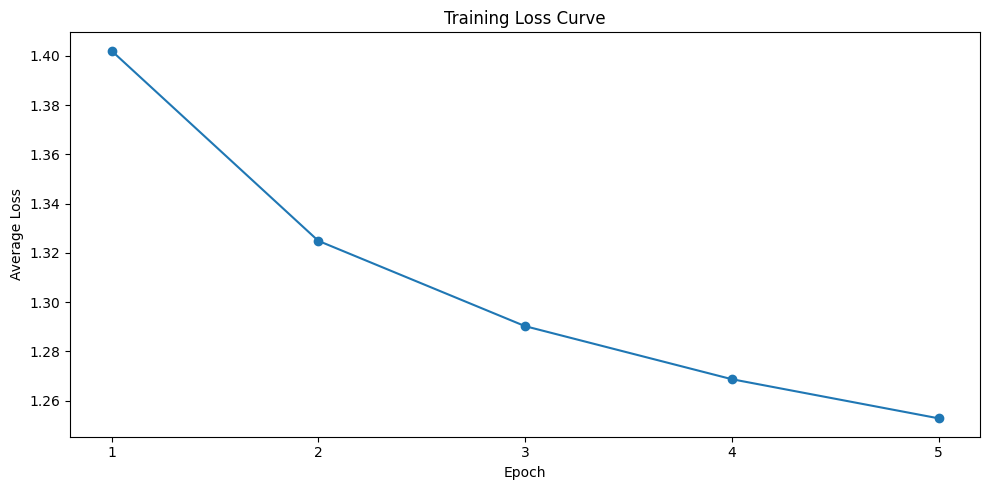

Loss curve saved to results/loss_curve.png


In [8]:
model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
epoch_losses_high_lr = train(model, train_loader, optimizer, criterion, device, EPOCHS, '../models')

In [ ]:
model = NRMSModel(embedding_matrix, NUM_HEADS, HEAD_DIM, dropout=0.4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
epoch_losses_high_dropout = train(model, train_loader, optimizer, criterion, device, EPOCHS, '../models')

In [ ]:
from src.evaluate import evaluate

for name in ['baseline', 'high_lr', 'high_dropout']:
    print(f'\n--- Evaluating {name} ---')
    model.load_state_dict(torch.load(f'../models/{name}_final.pt'))
    metrics = evaluate(model, dev_loader, device)